In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random
from scipy.spatial.distance import cdist # Nearest neighbor classification
import altair as alt
from sklearn.decomposition import KernelPCA
from sklearn.neighbors import KNeighborsClassifier



## Load Yale Faces Dataset

Number of persons: 15

n_train = 4, n_test = 1 (randomly selected from remaining 7)
Training set: 60 images
Test set: 15 images
Feature dimension: 77760
Image size: (243, 320)
Training matrix: (60, 77760), Test matrix: (15, 77760)


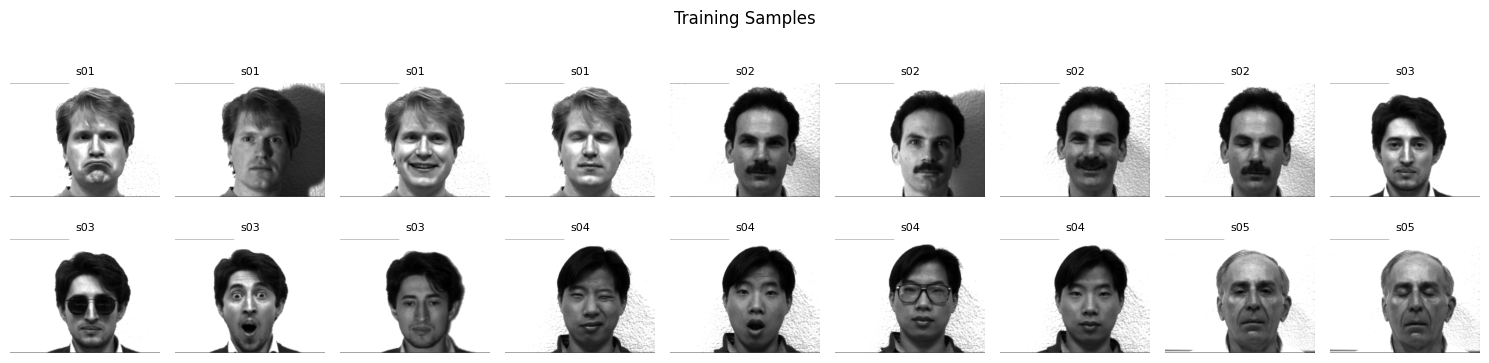

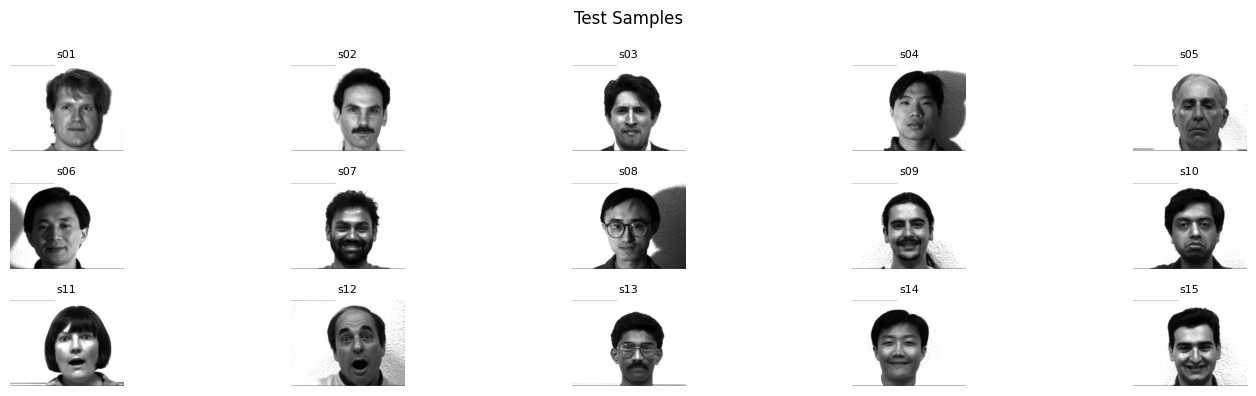

In [2]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, seed=42):
    """
    Split data: randomly select n_train images for training per person,
    then randomly select 1 image from the remaining as test.
    """
    random.seed(seed)
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        if len(imgs) <= n_train:
            raise ValueError(
                f"Person '{label}' has only {len(imgs)} images, "
                f"need at least {n_train + 1} (n_train={n_train} + 1 for test)."
            )
        indices = list(range(len(imgs)))
        random.shuffle(indices)

        train_indices = indices[:n_train]
        remaining = indices[n_train:]
        test_index = random.choice(remaining)

        for i in train_indices:
            train_imgs.append(imgs[i])
            train_labels.append(label)

        test_imgs.append(imgs[test_index])
        test_labels.append(label)

    return train_imgs, train_labels, test_imgs, test_labels


# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")
# for label, imgs in persons.items():
#    print(f"  {label}: {len(imgs)} images, size {imgs[0].shape}")

n_train = 4 # example : as there are 4 training image for each person

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

n_imgs_per_person = len(next(iter(persons.values())))
print(f"\nn_train = {n_train}, n_test = 1 (randomly selected from remaining {n_imgs_per_person - n_train})")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(2, 9, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

## Compute mean face and eigenfaces under different n_train

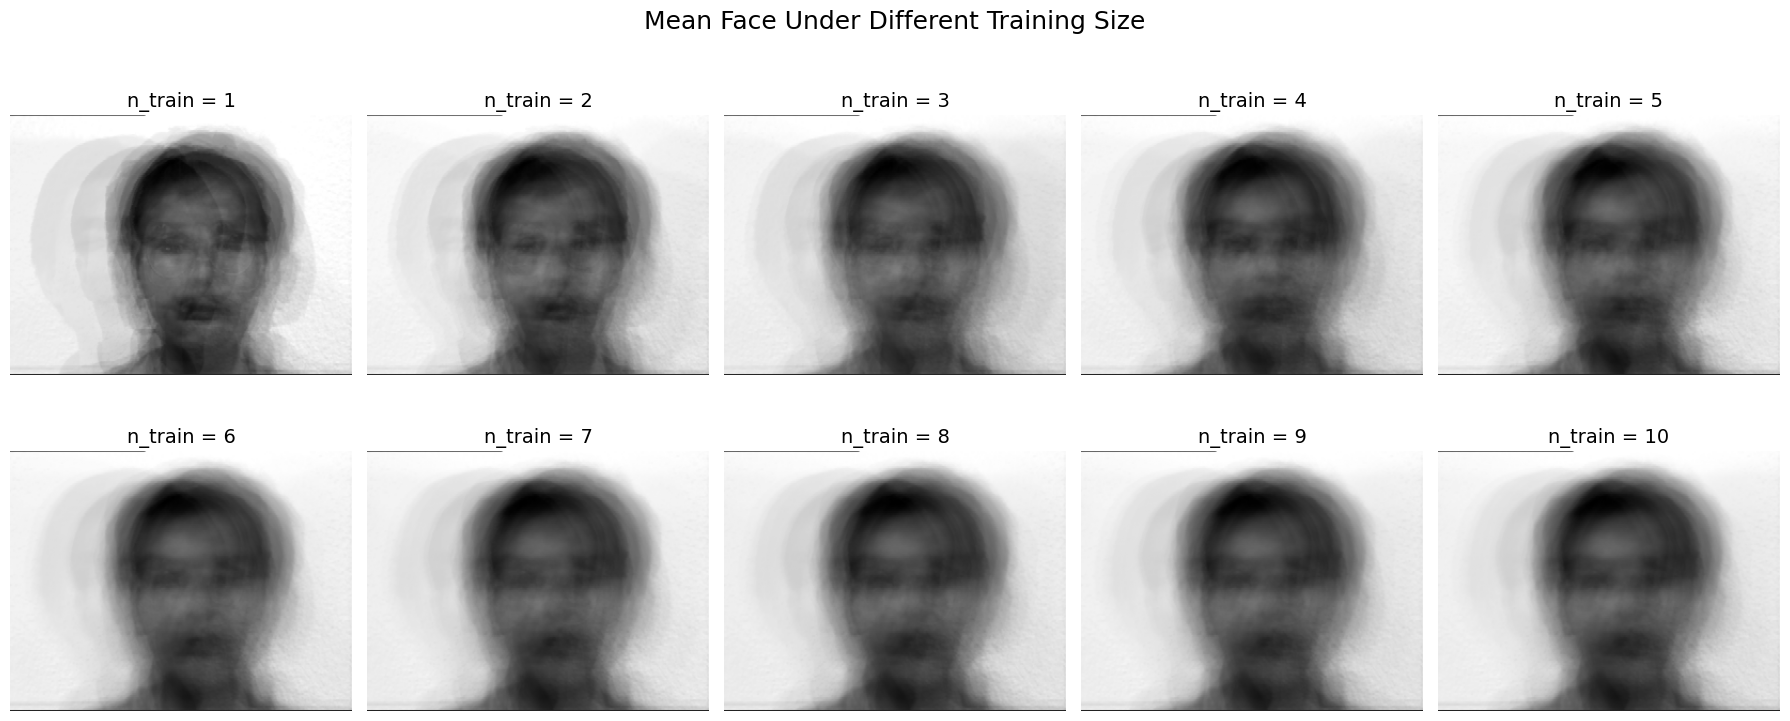

In [3]:
n_train_list = list(range(1, 11))
mean_faces = []
top3_eigenfaces = []

for n_tr in n_train_list:
    tr_imgs, _, _, _ = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs[:, :3]  # only compute top 3
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # Store as small images, not full vectors
    mean_faces.append(mf.reshape(243, 320))
    top3_eigenfaces.append([evecs[:, j].reshape(243, 320) for j in range(3)])

    # Free memory
    del X_tr, X_tr_c, small_cov, evals, small_evecs, evecs



# Visualize mean faces
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, n_tr in enumerate(n_train_list):
    ax = axes[i // 5, i % 5]
    ax.imshow(mean_faces[i], cmap='gray')
    ax.set_title(f"n_train = {n_tr}", fontsize=14,)
    ax.axis('off')
plt.suptitle("Mean Face Under Different Training Size", fontsize=18)
plt.tight_layout()
plt.show()

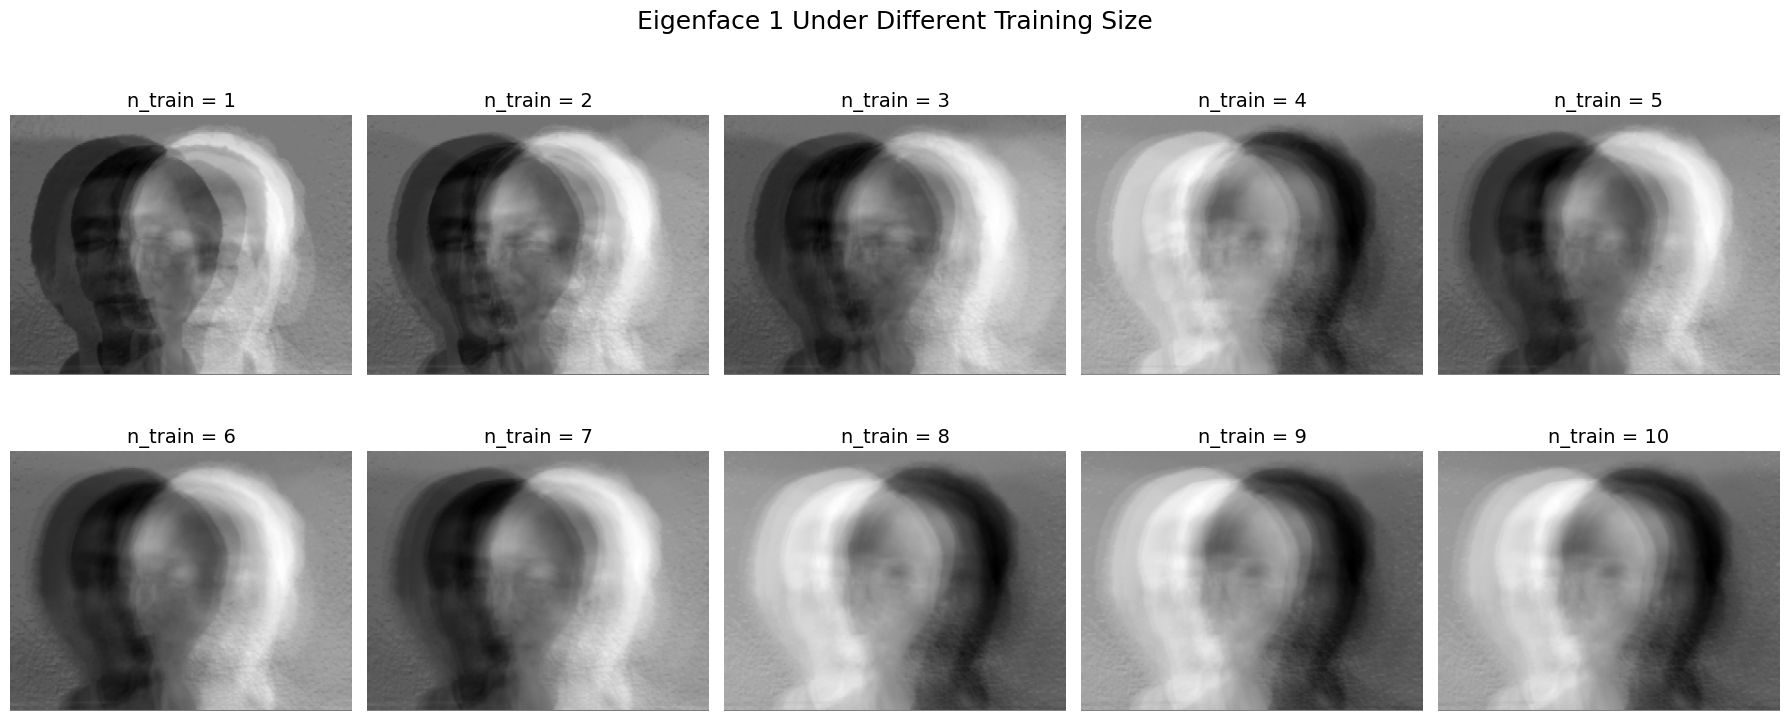

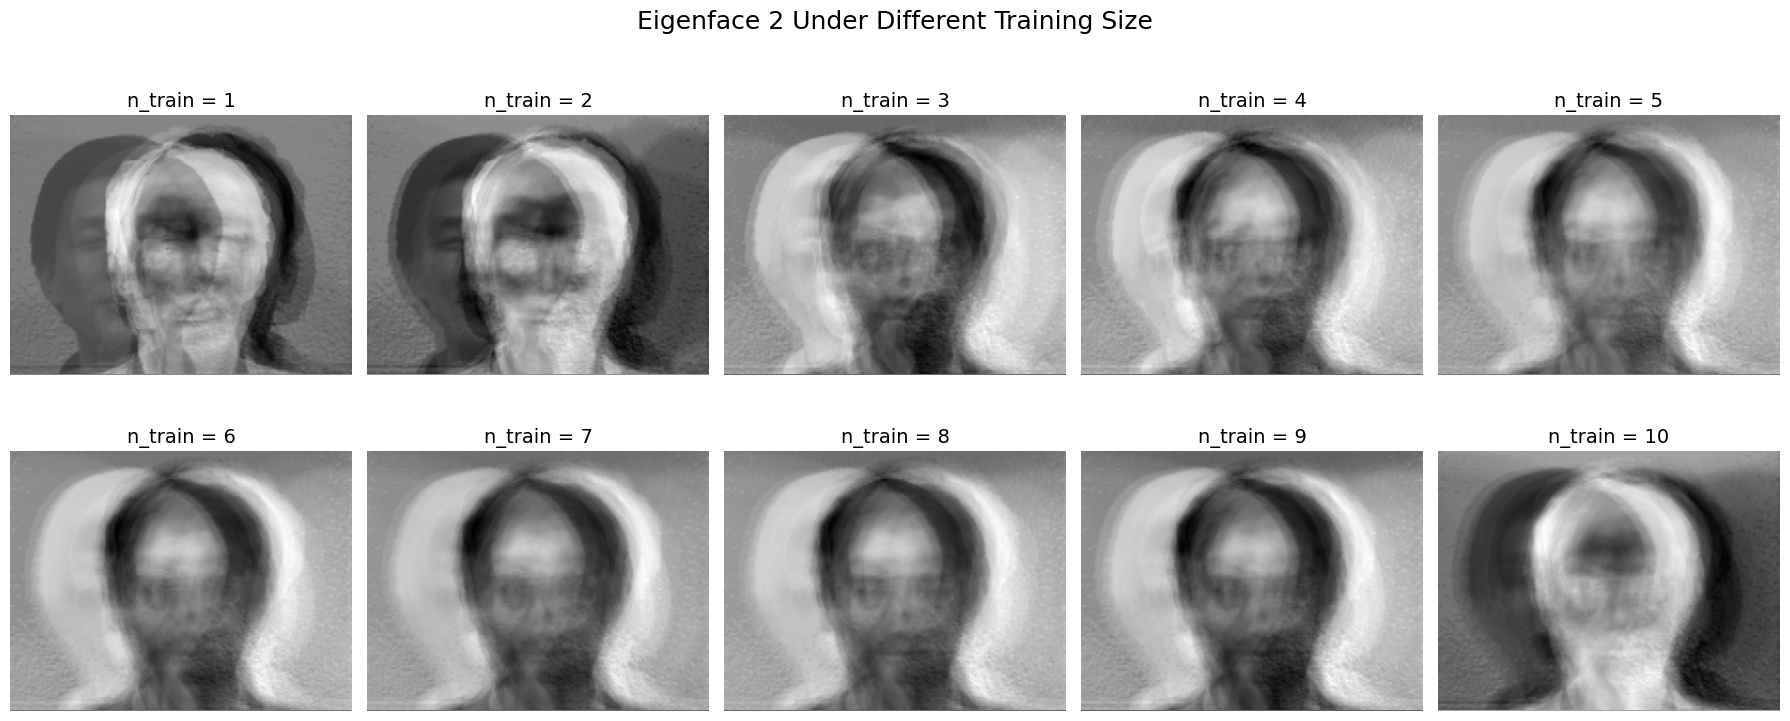

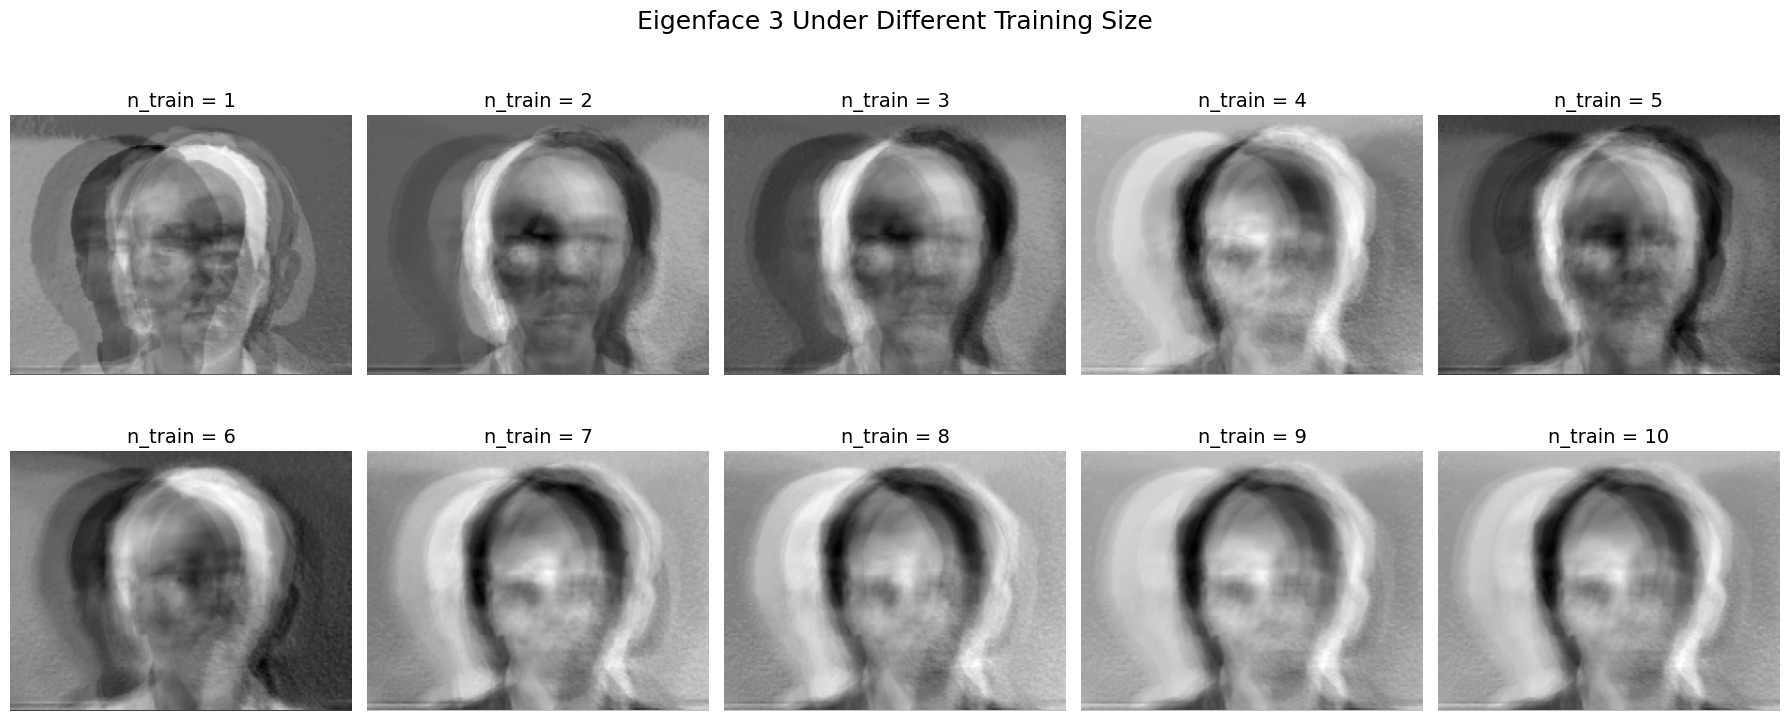

In [4]:
# Visualize top 3 eigenfaces under different n_train

for ef_idx in range(3):
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    for i, n_tr in enumerate(n_train_list):
        ax = axes[i // 5, i % 5]
        ax.imshow(top3_eigenfaces[i][ef_idx], cmap='gray')
        ax.set_title(f"n_train = {n_tr}", fontsize=14)
        ax.axis('off')
    plt.suptitle(f"Eigenface {ef_idx + 1} Under Different Training Size", fontsize=18)
    plt.tight_layout()
    plt.show()

## Cumulative Variance Curve under different n_train

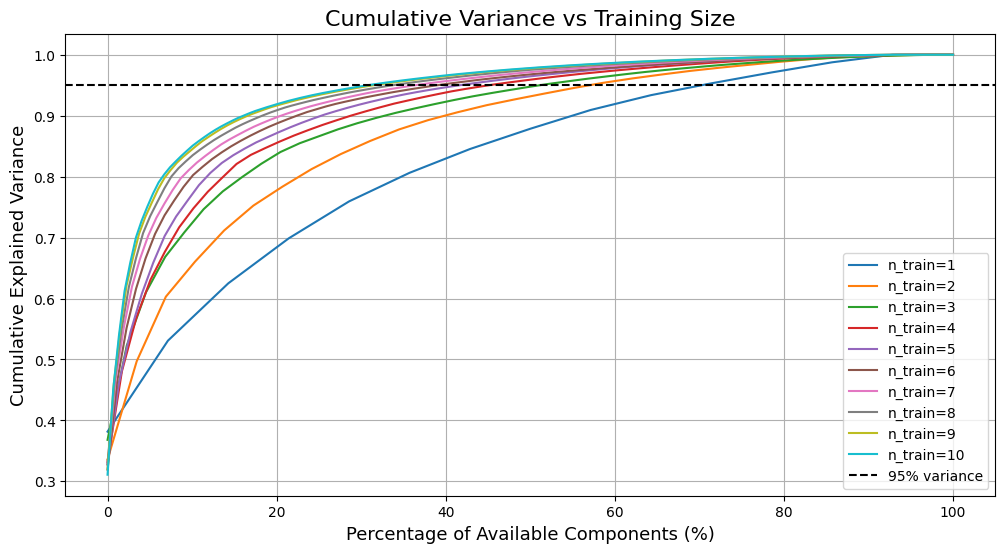

Components needed for 95% variance:
  n_train =  1 | k_95 =  11 | max components = 15
  n_train =  2 | k_95 =  18 | max components = 30
  n_train =  3 | k_95 =  24 | max components = 45
  n_train =  4 | k_95 =  28 | max components = 60
  n_train =  5 | k_95 =  32 | max components = 75
  n_train =  6 | k_95 =  36 | max components = 90
  n_train =  7 | k_95 =  39 | max components = 105
  n_train =  8 | k_95 =  42 | max components = 120
  n_train =  9 | k_95 =  44 | max components = 135
  n_train = 10 | k_95 =  47 | max components = 150


In [5]:
n_train_list = list(range(1, 11))
cum_var_data = {}
k95_data = {}

for n_tr in n_train_list:
    tr_imgs, _, _, _ = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, _ = np.linalg.eigh(small_cov)
    evals = np.sort(evals)[::-1]

    ratio = evals / np.sum(evals)
    cum_var = np.cumsum(ratio)
    k95 = np.argmax(cum_var >= 0.95) + 1

    cum_var_data[n_tr] = cum_var
    k95_data[n_tr] = k95

    del X_tr, X_tr_c, small_cov, evals

# Plot cumulative variance curves (percentage of available components)
plt.figure(figsize=(12, 6))
for n_tr in n_train_list:
    cv = cum_var_data[n_tr]
    x_pct = np.linspace(0, 100, len(cv))
    plt.plot(x_pct, cv, label=f"n_train={n_tr}")
plt.axhline(y=0.95, color='k', linestyle='--', linewidth=1.5, label='95% variance')
plt.xlabel("Percentage of Available Components (%)", fontsize=13)
plt.ylabel("Cumulative Explained Variance", fontsize=13)
plt.title("Cumulative Variance vs Training Size", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

# Print k_95 for each n_train
print("Components needed for 95% variance:")
for n_tr in n_train_list:
    max_k = len(cum_var_data[n_tr])
    print(f"  n_train = {n_tr:>2d} | k_95 = {k95_data[n_tr]:>3d} | max components = {max_k}")

In [6]:
# Altair Slider
# Build dataframe
rows = []
for n_tr in n_train_list:
    cv = cum_var_data[n_tr]
    x_pct = np.linspace(0, 100, len(cv))
    for j in range(len(cv)):
        rows.append({
            'n_train': n_tr,
            'pct_components': x_pct[j],
            'cum_variance': cv[j]
        })

df = pd.DataFrame(rows)

# Slider for minimum n_train
slider = alt.binding_range(min=1, max=10, step=1, name='Min n_train: ')
selection = alt.param(name='min_ntrain', value=1, bind=slider)
train_select = alt.selection_point(fields= ['n_train'], empty = 'all')

# Chart
chart = alt.Chart(df).mark_line(point=False).encode(
    x=alt.X('pct_components:Q', title='Percentage of Available Components (%)'),
    y=alt.Y('cum_variance:Q', title='Cumulative Explained Variance', scale=alt.Scale(domain=[0.3, 1.05])),
    color=alt.Color('n_train:N', title='n_train',
        sort=list(range(1, 11)),
        scale=alt.Scale(
            domain=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            range=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        )
    ),
    tooltip=[
        alt.Tooltip('n_train:N', title='n_train'),
        alt.Tooltip('pct_components:Q', title='Components %', format='.1f'),
        alt.Tooltip('cum_variance:Q', title='Variance', format='.4f')
    ]
).add_params(
    selection
).transform_filter(
    alt.datum.n_train >= selection
).properties(
    title='Cumulative Variance vs Training Size',
    width=700,
    height=400
)

# 95% reference line
rule = alt.Chart(pd.DataFrame({'y': [0.95]})).mark_rule(
    strokeDash=[5, 5], color='black', strokeWidth=1.5
).encode(y='y:Q')

(chart + rule)

alt.LayerChart(...)

In [7]:
# === Euclidean Distance ===
# Effect of k on Accuracy for Varying Training Sizes

n_train_list = list(range(1, 11))
accuracy_data = {}

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    max_k = evecs.shape[1]
    k_list = list(range(1, max_k + 1, max(1, max_k // 20))) + [max_k]
    k_list = sorted(set(k_list))

    accs = []
    for k in k_list:
        W = evecs[:, :k]
        X_tr_p = X_tr_c @ W
        X_te_p = X_te_c @ W
        dists = cdist(X_te_p, X_tr_p, metric='euclidean')
        preds = y_tr[np.argmin(dists, axis=1)]
        accs.append(np.mean(preds == y_te) * 100)

    accuracy_data[n_tr] = {'k_list': k_list, 'accuracy': accs}
    print(f"n_train = {n_tr:>2d} | max_k = {max_k:>3d} | best accuracy = {max(accs):.2f}% at k = {k_list[np.argmax(accs)]}")

    del X_tr, X_te, X_tr_c, X_te_c, small_cov, evals, small_evecs, evecs


n_train =  1 | max_k =  15 | best accuracy = 66.67% at k = 11


n_train =  2 | max_k =  30 | best accuracy = 73.33% at k = 17


n_train =  3 | max_k =  45 | best accuracy = 80.00% at k = 11


n_train =  4 | max_k =  60 | best accuracy = 86.67% at k = 22


n_train =  5 | max_k =  75 | best accuracy = 86.67% at k = 13


n_train =  6 | max_k =  90 | best accuracy = 80.00% at k = 25


n_train =  7 | max_k = 105 | best accuracy = 66.67% at k = 11


n_train =  8 | max_k = 120 | best accuracy = 100.00% at k = 55


n_train =  9 | max_k = 135 | best accuracy = 93.33% at k = 19


n_train = 10 | max_k = 150 | best accuracy = 86.67% at k = 71


In [8]:
# === Mahalanobis Distance ===
n_train_list = list(range(1, 11))
accuracy_data = {}

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    max_k = evecs.shape[1]
    k_list = list(range(1, max_k + 1, max(1, max_k // 20))) + [max_k]
    k_list = sorted(set(k_list))

    accs = []
    for k in k_list:
        W = evecs[:, :k]
        X_tr_p = X_tr_c @ W
        X_te_p = X_te_c @ W
        dists = cdist(X_te_p, X_tr_p, metric='mahalanobis')
        preds = y_tr[np.argmin(dists, axis=1)]
        accs.append(np.mean(preds == y_te) * 100)

    accuracy_data[n_tr] = {'k_list': k_list, 'accuracy': accs}
    print(f"n_train = {n_tr:>2d} | max_k = {max_k:>3d} | best accuracy = {max(accs):.2f}% at k = {k_list[np.argmax(accs)]}")

    del X_tr, X_te, X_tr_c, X_te_c, small_cov, evals, small_evecs, evecs


n_train =  1 | max_k =  15 | best accuracy = 53.33% at k = 7


n_train =  2 | max_k =  30 | best accuracy = 80.00% at k = 7


n_train =  3 | max_k =  45 | best accuracy = 86.67% at k = 29


n_train =  4 | max_k =  60 | best accuracy = 86.67% at k = 22


n_train =  5 | max_k =  75 | best accuracy = 100.00% at k = 37


n_train =  6 | max_k =  90 | best accuracy = 86.67% at k = 25


n_train =  7 | max_k = 105 | best accuracy = 80.00% at k = 26


n_train =  8 | max_k = 120 | best accuracy = 100.00% at k = 37


n_train =  9 | max_k = 135 | best accuracy = 93.33% at k = 13


n_train = 10 | max_k = 150 | best accuracy = 86.67% at k = 15


In [9]:
# === Cosine Distance ===
n_train_list = list(range(1, 11))
accuracy_data = {}

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    max_k = evecs.shape[1]
    k_list = list(range(1, max_k + 1, max(1, max_k // 20))) + [max_k]
    k_list = sorted(set(k_list))

    accs = []
    for k in k_list:
        W = evecs[:, :k]
        X_tr_p = X_tr_c @ W
        X_te_p = X_te_c @ W
        dists = cdist(X_te_p, X_tr_p, metric='cosine')
        preds = y_tr[np.argmin(dists, axis=1)]
        accs.append(np.mean(preds == y_te) * 100)

    accuracy_data[n_tr] = {'k_list': k_list, 'accuracy': accs}
    print(f"n_train = {n_tr:>2d} | max_k = {max_k:>3d} | best accuracy = {max(accs):.2f}% at k = {k_list[np.argmax(accs)]}")

    del X_tr, X_te, X_tr_c, X_te_c, small_cov, evals, small_evecs, evecs


n_train =  1 | max_k =  15 | best accuracy = 66.67% at k = 9


n_train =  2 | max_k =  30 | best accuracy = 66.67% at k = 15


n_train =  3 | max_k =  45 | best accuracy = 80.00% at k = 11


n_train =  4 | max_k =  60 | best accuracy = 86.67% at k = 25


n_train =  5 | max_k =  75 | best accuracy = 80.00% at k = 7


n_train =  6 | max_k =  90 | best accuracy = 73.33% at k = 9


n_train =  7 | max_k = 105 | best accuracy = 66.67% at k = 11


n_train =  8 | max_k = 120 | best accuracy = 86.67% at k = 55


n_train =  9 | max_k = 135 | best accuracy = 93.33% at k = 19


n_train = 10 | max_k = 150 | best accuracy = 80.00% at k = 57


In [10]:
n_train_list = list(range(1, 11))
metrics = ['euclidean', 'cosine', 'mahalanobis']
metric_rows = []

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    max_k = evecs.shape[1]
    k_list = list(range(1, max_k + 1, max(1, max_k // 20))) + [max_k]
    k_list = sorted(set(k_list))

    for metric in metrics:
        for k in k_list:
            W = evecs[:, :k]
            X_tr_p = X_tr_c @ W
            X_te_p = X_te_c @ W

            if metric == 'mahalanobis':
                cov = np.cov(X_tr_p, rowvar=False)
                try:
                    VI = np.linalg.inv(np.atleast_2d(cov))
                    dists = cdist(X_te_p, X_tr_p, metric='mahalanobis', VI=VI)
                except np.linalg.LinAlgError:
                    # Singular covariance — record NaN and skip
                    metric_rows.append({
                        'n_train': n_tr, 'k': k, 'k_pct': k / max_k * 100,
                        'Metric': 'Mahalanobis', 'Accuracy': np.nan
                    })
                    continue
            else:
                dists = cdist(X_te_p, X_tr_p, metric=metric)

            preds = y_tr[np.argmin(dists, axis=1)]
            acc = np.mean(preds == y_te) * 100

            metric_rows.append({
                'n_train': n_tr,
                'k': k,
                'k_pct': k / max_k * 100,
                'Metric': metric.capitalize(),
                'Accuracy': acc
            })

    del X_tr, X_te, X_tr_c, X_te_c, small_cov, evals, small_evecs, evecs

df_metrics = pd.DataFrame(metric_rows)

metric_dropdown = alt.binding_select(
    options=['Euclidean', 'Cosine', 'Mahalanobis'],
    name='Metric: '
)
metric_select = alt.selection_point(
    fields=['Metric'], bind=metric_dropdown, value='Euclidean'
)

slider = alt.binding_range(min=1, max=10, step=1, name='Min n_train: ')
ntrain_param = alt.param(name='min_ntrain', value=1, bind=slider)

color_scale = alt.Scale(
    domain=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    range=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
)

chart_metrics = alt.Chart(df_metrics).mark_line(point=True, interpolate='monotone').encode(
    x=alt.X('k_pct:Q', title='Percentage of Available Components (%)'),
    y=alt.Y('Accuracy:Q', title='Accuracy (%)', scale=alt.Scale(domain=[0, 105])),
    color=alt.Color('n_train:N', title='n_train',
                    sort=list(range(1, 11)), scale=color_scale),
    tooltip=[
        alt.Tooltip('n_train:N', title='n_train'),
        alt.Tooltip('Metric:N', title='Metric'),
        alt.Tooltip('k:Q', title='k'),
        alt.Tooltip('k_pct:Q', title='k (%)', format='.1f'),
        alt.Tooltip('Accuracy:Q', title='Accuracy (%)', format='.2f'),
    ]
).add_params(
    metric_select,
    ntrain_param
).transform_filter(
    metric_select
).transform_filter(
    alt.datum.n_train >= ntrain_param
).properties(
    title='PCA Accuracy vs k: Distance Metric Comparison under Different Training Sizes',
    width=720,
    height=420
)

chart_metrics

alt.Chart(...)

n_train = 2 | Total training: 30 | k_95 = 18 | Max k = 30 | Accuracy: 73.33%
n_train = 3 | Total training: 45 | k_95 = 24 | Max k = 45 | Accuracy: 80.00%
n_train = 5 | Total training: 75 | k_95 = 32 | Max k = 75 | Accuracy: 86.67%


n_train = 7 | Total training: 105 | k_95 = 39 | Max k = 105 | Accuracy: 66.67%
n_train = 9 | Total training: 135 | k_95 = 44 | Max k = 135 | Accuracy: 93.33%


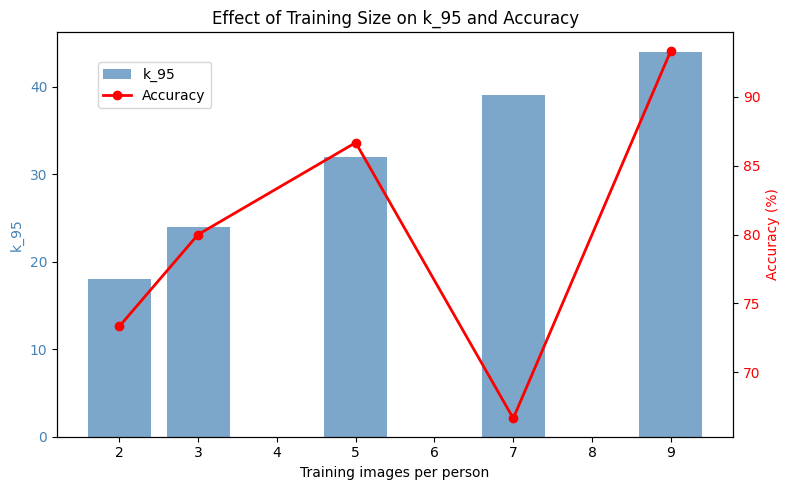

In [11]:
# ============================================================
# Compare k_95 under different training sizes
# ============================================================

n_train_list = [2, 3, 5, 7, 9]
results = []

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])

    # Center
    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    # Small matrix trick
    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # Cumulative variance
    ratio = evals / np.sum(evals)
    cum_var = np.cumsum(ratio)
    k95 = np.argmax(cum_var >= 0.95) + 1

    # Accuracy at k_95
    W = evecs[:, :k95]
    X_tr_p = X_tr_c @ W
    X_te_p = X_te_c @ W
    dists = cdist(X_te_p, X_tr_p, metric='euclidean')
    preds = np.array(tr_labels)[np.argmin(dists, axis=1)]
    acc = np.mean(preds == np.array(te_labels)) * 100

    results.append({'n_train': n_tr, 'total_train': n * 1, 'k_95': k95, 'max_k': n, 'accuracy': acc})
    print(f"n_train = {n_tr} | Total training: {X_tr.shape[0]} | k_95 = {k95} | Max k = {X_tr.shape[0]} | Accuracy: {acc:.2f}%")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

n_trains = [r['n_train'] for r in results]
k95s = [r['k_95'] for r in results]
accs = [r['accuracy'] for r in results]

ax1.bar(n_trains, k95s, color='steelblue', alpha=0.7, label='k_95')
ax1.set_xlabel('Training images per person')
ax1.set_ylabel('k_95', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(n_trains, accs, 'ro-', linewidth=2, label='Accuracy')
ax2.set_ylabel('Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Effect of Training Size on k_95 and Accuracy')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

## PCA + LDA (Fisherfaces) vs PCA-only

PCA finds directions of maximum *variance* without using labels. LDA adds class supervision: it solves the generalized eigenvalue problem

$$S_B \, w = \lambda \, S_W \, w$$

where $S_W$ is the within-class scatter and $S_B$ is the between-class scatter. The result is a projection that maximizes class separation.

Below we compare PCA-only vs PCA+LDA (Fisherfaces) across different training sizes, with LDA implemented from scratch using the same approach as in the KPCA notebook.

n_train= 2  |  PCA:  73.33%  |  PCA+LDA:  80.00%  |  diff: +6.67%


n_train= 3  |  PCA:  80.00%  |  PCA+LDA:  93.33%  |  diff: +13.33%


n_train= 4  |  PCA:  86.67%  |  PCA+LDA:  93.33%  |  diff: +6.67%


n_train= 5  |  PCA:  86.67%  |  PCA+LDA: 100.00%  |  diff: +13.33%


n_train= 6  |  PCA:  80.00%  |  PCA+LDA:  93.33%  |  diff: +13.33%


n_train= 7  |  PCA:  66.67%  |  PCA+LDA:  93.33%  |  diff: +26.67%


n_train= 8  |  PCA: 100.00%  |  PCA+LDA: 100.00%  |  diff: +0.00%


n_train= 9  |  PCA:  93.33%  |  PCA+LDA: 100.00%  |  diff: +6.67%


n_train=10  |  PCA:  86.67%  |  PCA+LDA: 100.00%  |  diff: +13.33%


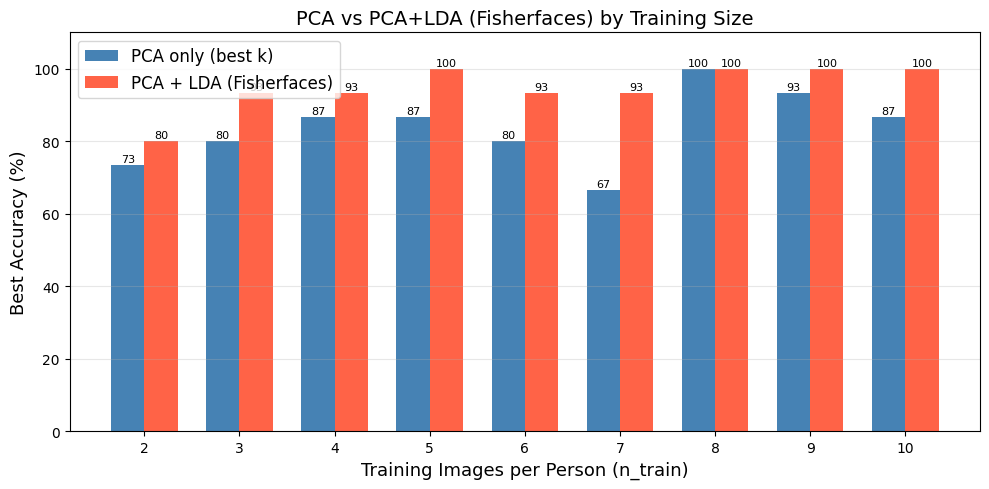

n_train      PCA-only    PCA+LDA  Improvement
---------------------------------------------
2              73.33%     80.00%      +6.67%
3              80.00%     93.33%     +13.33%
4              86.67%     93.33%      +6.67%
5              86.67%    100.00%     +13.33%
6              80.00%     93.33%     +13.33%
7              66.67%     93.33%     +26.67%
8             100.00%    100.00%      +0.00%
9              93.33%    100.00%      +6.67%
10             86.67%    100.00%     +13.33%


In [12]:
from scipy.linalg import eigh as generalized_eigh

n_train_list = list(range(2, 11))
pca_only_best = []
lda_best = []

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # --- PCA-only best accuracy (sweep k, Euclidean 1-NN) ---
    best_pca = 0
    for k in range(1, n + 1):
        W = evecs[:, :k]
        dists = cdist(X_te_c @ W, X_tr_c @ W, metric='euclidean')
        preds = y_tr[np.argmin(dists, axis=1)]
        acc = np.mean(preds == y_te)
        if acc > best_pca:
            best_pca = acc
    pca_only_best.append(best_pca * 100)

    # --- PCA + LDA from scratch (sweep PCA_k) ---
    classes = np.unique(y_tr)
    C = len(classes)
    best_lda = 0

    for pca_k in range(C, n):
        W = evecs[:, :pca_k]
        Z_tr = X_tr_c @ W
        Z_te = X_te_c @ W
        d = pca_k

        # Class means and global mean
        mu = np.mean(Z_tr, axis=0)

        # Within-class scatter S_W
        S_W = np.zeros((d, d))
        for c in classes:
            mask = y_tr == c
            Z_c = Z_tr[mask] - np.mean(Z_tr[mask], axis=0)
            S_W += Z_c.T @ Z_c

        # Between-class scatter S_B
        S_B = np.zeros((d, d))
        for c in classes:
            mask = y_tr == c
            diff = (np.mean(Z_tr[mask], axis=0) - mu).reshape(-1, 1)
            S_B += np.sum(mask) * (diff @ diff.T)

        # Generalized eigenvalue problem: S_B w = lambda S_W w
        eps = 1e-6 * np.trace(S_W) / d
        try:
            ev_lda, ec_lda = generalized_eigh(S_B, S_W + eps * np.eye(d))
            idx_lda = np.argsort(ev_lda)[::-1]
            ec_lda = ec_lda[:, idx_lda]
        except Exception:
            continue

        # Sweep LDA dimensions r = 1 to C-1
        max_r = C - 1
        for r in range(1, max_r + 1):
            W_lda = ec_lda[:, :r]
            Z_tr_l = Z_tr @ W_lda
            Z_te_l = Z_te @ W_lda
            dists = cdist(Z_te_l, Z_tr_l, metric='euclidean')
            preds = y_tr[np.argmin(dists, axis=1)]
            acc = np.mean(preds == y_te)
            if acc > best_lda:
                best_lda = acc

    lda_best.append(best_lda * 100)

    print(f"n_train={n_tr:>2d}  |  PCA: {pca_only_best[-1]:6.2f}%  |  PCA+LDA: {lda_best[-1]:6.2f}%  |  diff: {lda_best[-1]-pca_only_best[-1]:+.2f}%")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.array(n_train_list)
width = 0.35

bars1 = ax.bar(x - width/2, pca_only_best, width, label='PCA only (best k)', color='steelblue')
bars2 = ax.bar(x + width/2, lda_best, width, label='PCA + LDA (Fisherfaces)', color='tomato')

ax.set_xlabel('Training Images per Person (n_train)', fontsize=13)
ax.set_ylabel('Best Accuracy (%)', fontsize=13)
ax.set_title('PCA vs PCA+LDA (Fisherfaces) by Training Size', fontsize=14)
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.8, f'{h:.0f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.8, f'{h:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Table ---
print(f"{'n_train':<10} {'PCA-only':>10} {'PCA+LDA':>10} {'Improvement':>12}")
print('-' * 45)
for i, n_tr in enumerate(n_train_list):
    diff = lda_best[i] - pca_only_best[i]
    print(f"{n_tr:<10} {pca_only_best[i]:>9.2f}% {lda_best[i]:>9.2f}% {diff:>+10.2f}%")
